In [10]:
%load_ext autoreload
%autoreload 2
import holodeck as holo
from holodeck import librarian
import numpy as np
import matplotlib.pyplot as plt
from holodeck.constants import MSOL
import holodeck.sams as sams
from astropy.cosmology import WMAP9 as cosmo
from scipy.stats import norm as stnorm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Analytical Expressions


## 1. Calculating the GSMF
https://en.wikipedia.org/wiki/Luminosity_function_(astronomy)

The GSMF can be expressed as a sum of two Schechter functions. (Using one is less accurate, but can be used as an approximate form)


$$\Phi(M_\star)  = \ln(10) \, \exp\left[ -\frac{M_\star}{M_\mathrm{c}} \right] \times
\Bigg( \phi_{*, 1} \left( \frac{M_\star}{M_\mathrm{c}} \right)^{\alpha_1+1} 
+ \, \phi_{*, 2} \left( \frac{M_\star}{M_\mathrm{c}} \right)^{\alpha_2+1} \Bigg) (1)$$


$\Phi(M_\star)$ is the number of galaxies (per unit galaxy mass) within a given volume, i.e. the number density.

$M_\mathrm{c}$ is the characteristic mass

$\phi_{*, 1}$ and $\phi_{*, 2}$ are the density normalizations

$\alpha_1$ and $\alpha_2$ are the slopes

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/var/folders/7z/7081q7x964b7rf4h4sy5t4qw0000gs/T/ipykernel_94433/1585366072.py:23: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log (\Phi / \mathrm{Mpc}^{-3} /\mathrm{dex})$', fontsize=25)


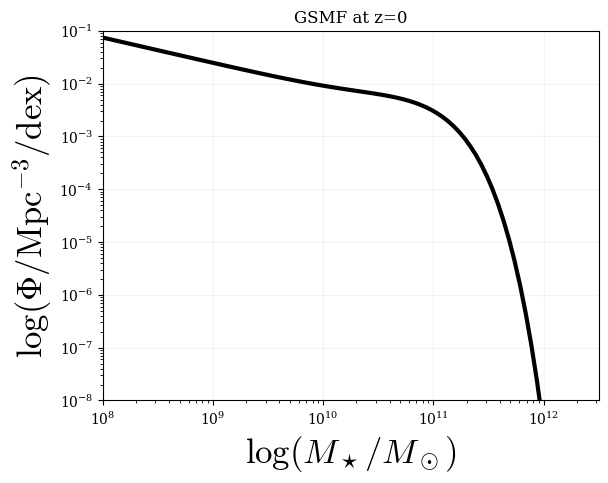

In [11]:
logm = np.logspace(8, 13, 100) # log stellar mass

# This is the equation for a double Schechter function. This version does not change with redshift. The input parameters are from Leja et al. (2020) for z = 0
# See what happens when you change these values
phi1 = -2.383
phi2 = -2.818
mchar = 10.767
alpha1 = -0.28
alpha2 = -1.48

masses = np.linspace(8, 13, 100) # log stellar mass

xx = 10**masses / 10**mchar
t1 = 10**phi1 * xx**(alpha1 + 1)
t2 = 10**phi2 * xx**(alpha2 + 1)
test2 = (t1 + t2) * np.exp(-xx) * np.log(10)

plt.plot(10**masses, test2, lw=3, color='black')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\log (M_\star / M_\odot)$', fontsize=25)
plt.ylabel('$\log (\Phi / \mathrm{Mpc}^{-3} /\mathrm{dex})$', fontsize=25)
plt.title('GSMF at z=0')
plt.ylim(1e-8, 1e-1)
plt.xlim(1e8, 10**12.5);

The real GSMF changes with redshift. You can add terms to the Schechter function to make it evolve with z. Leja et al. (2020) found an analytic solution to this evolution:

$$\Phi(M_\star, z)  = \ln(10) \, \exp\left[ -\frac{M_\star}{M_\mathrm{c}(z)} \right] \times
\Bigg( \phi_{*, 1}(z) \left( \frac{M_\star}{M_\mathrm{c}(z)} \right)^{\alpha_1+1} 
+ \, \phi_{*, 2}(z) \left( \frac{M_\star}{M_\mathrm{c}(z)} \right)^{\alpha_2+1} \Bigg) (2)$$

$$\log \phi_{*, i}(z) = {\phi_{*, i,0} + \phi_{*, i,1}  z + \phi_{*, i,2}  z^2} (3)$$

$$\log M_\mathrm{c}(z) =  {M_{\mathrm{c} ,0} + M_{\mathrm{c} ,1}  z + M_{\mathrm{c} ,2}  z^2} (4)$$

In [12]:
def get_gsmf(logMass, dct, redz):
    """
    This function defines the double-Schechter galaxy stellar mass function (GSMF) from the parameters in the input dictionary `dct` at a given redshift `redz`.
    Parameters
    ----------
    logMass : float or array-like
    dct : dict
        Dictionary containing the GSMF parameters with keys:
        'gsmf_log10_phi_one_z0', 'gsmf_log10_phi_one_z1', 'gsmf_log10_phi_one_z2',
        'gsmf_log10_phi_two_z0', 'gsmf_log10_phi_two_z1', 'gsmf_log10_phi_two_z2',
        'gsmf_log10_mstar_z0', 'gsmf_log10_mstar_z1', 'gsmf_log10_mstar_z2',
        'gsmf_alpha_one', 'gsmf_alpha_two'
    redz : float

    Returns
    -------
    rv : float or array-like
        The value of the GSMF at the given logMass and redz.
    """
    log10_phi1 = [dct['gsmf_log10_phi_one_z0'], dct['gsmf_log10_phi_one_z1'], dct['gsmf_log10_phi_one_z2']] # [phi_{*, 1, 0}, phi_{*, 1, 1}, phi_{*, 1, 2}]
    log10_phi2 = [dct['gsmf_log10_phi_two_z0'], dct['gsmf_log10_phi_two_z1'], dct['gsmf_log10_phi_two_z2']] # [phi_{*, 2, 0}, phi_{*, 2, 1}, phi_{*, 2, 2}]
    log10_mstar = [dct['gsmf_log10_mstar_z0'], dct['gsmf_log10_mstar_z1'], dct['gsmf_log10_mstar_z2']] # [log10(M_{c, 0}), log10(M_{c, 1}), log10(M_{c, 2})]
    alpha1 = dct['gsmf_alpha_one']
    alpha2 = dct['gsmf_alpha_two']

    mstar = np.power(10.0, log10_mstar[0] + log10_mstar[1] * redz + log10_mstar[2] * redz**2) # Equation 4
    phi1 = np.power(10.0, log10_phi1[0] + log10_phi1[1] * redz + log10_phi1[2] * redz**2) # Equation 3
    phi2 = np.power(10.0, log10_phi2[0] + log10_phi2[1] * redz + log10_phi2[2] * redz**2) # Equation 3
    xx = logMass / mstar
    rv1 = np.log(10.0) * phi1 * np.power(xx, 1.0 + alpha1) * np.exp(-xx)
    rv2 = np.log(10.0) * phi2 * np.power(xx, 1.0 + alpha2) * np.exp(-xx)
    rv = rv1 + rv2
    
    return rv

<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
/var/folders/7z/7081q7x964b7rf4h4sy5t4qw0000gs/T/ipykernel_94433/3493598408.py:27: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log (\Phi / \mathrm{Mpc}^{-3} /\mathrm{dex})$', fontsize=25)


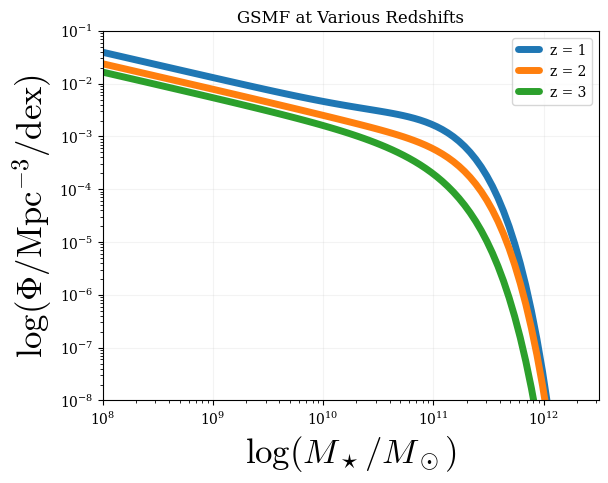

In [13]:
# Plotting the GSMF at z=0 calculated three ways

logm = np.logspace(8, 13, 100) # log stellar mass


# This is the equation for a double Schechter function that changes with redshift. The input parameters are from Leja et al. (2020)
gsmf_dct = {'gsmf_log10_phi_one_z0': -2.383,
        'gsmf_log10_phi_one_z1': -0.264,
        'gsmf_log10_phi_one_z2': -0.107,
        'gsmf_log10_phi_two_z0': -2.818,
        'gsmf_log10_phi_two_z1': -0.368,
        'gsmf_log10_phi_two_z2': 0.046,
        'gsmf_log10_mstar_z0': 10.767,
        'gsmf_log10_mstar_z1': 0.124,
        'gsmf_log10_mstar_z2': -0.033,
        'gsmf_alpha_one': -0.28,
        'gsmf_alpha_two': -1.48}

zval = 0 
for zval in [1, 2, 3]:# Redshift to evaluate GSMF at
        gsmf_examp1 = get_gsmf(logm, gsmf_dct, zval)
        plt.plot(logm, gsmf_examp1, lw=5, label='z = {}'.format(zval))

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\log (M_\star / M_\odot)$', fontsize=25)
plt.ylabel('$\log (\Phi / \mathrm{Mpc}^{-3} /\mathrm{dex})$', fontsize=25)
plt.title('GSMF at Various Redshifts')
plt.ylim(1e-8, 1e-1)
plt.xlim(1e8, 10**12.5)
plt.legend();

## 2. Calculating the Black Hole Mass Function (BHMF)


Like the GSMF, the BHMF tells us about the number density of black holes. You can calculate this analytically by convolving the GSMF with the black hole mass - galaxy mass scaling relation.

<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
/var/folders/7z/7081q7x964b7rf4h4sy5t4qw0000gs/T/ipykernel_94433/1681877832.py:29: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log (M_\mathrm{BH} / M_\odot)$', fontsize=25)
/var/folders/7z/7081q7x964b7rf4h4sy5t4qw0000gs/T/ipykernel_94433/1681877832.py:30: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log (\Phi / \mathrm{Mpc}^{-3} /\mathrm{dex})$', fontsize=25)
/var/folders/7z/7081q7x964b7rf4h4sy5t4qw0000gs/T/ipykernel_94433/1681877832.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bhmf_conv[i] = np.trapz(phi_gsmf * pdf, mstar)


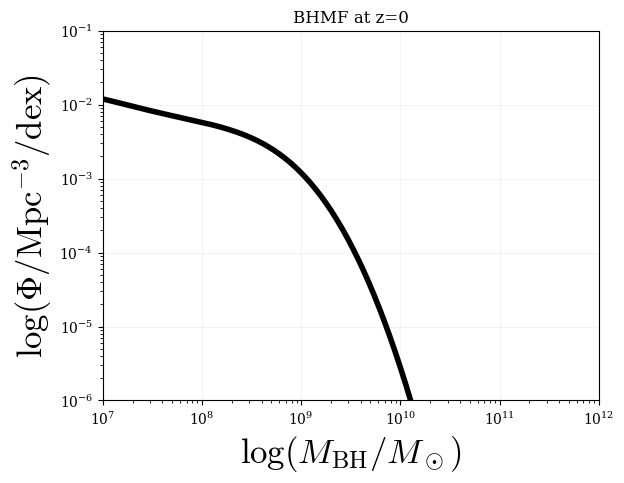

In [14]:
mstar = np.linspace(9, 12, 300)
mbh = np.linspace(5, 13, 300)

# Calculate GSMF at z=0

phi1 = -2.383
phi2 = -2.818
mchar = 10.767
alpha1 = -0.28
alpha2 = -1.48

xx = 10**mstar / 10**mchar
t1 = 10**phi1 * xx**(alpha1 + 1)
t2 = 10**phi2 * xx**(alpha2 + 1)
phi_gsmf = (t1 + t2) * np.exp(-xx) * np.log(10)

bhmf_conv = np.zeros_like(mbh)
logMbh_mean = 8.69 + 1.17 * (mstar - 11.0) # Calculate SMBH mass from the Kormendy & Ho (2013) relation

for i, logMbh in enumerate(mbh): # Convolve the GSMF with the Mbh-M* relation to get the BHMF
    pdf = stnorm.pdf(logMbh, loc=logMbh_mean, scale=0.28)
    bhmf_conv[i] = np.trapz(phi_gsmf * pdf, mstar)

plt.plot(10**mbh, bhmf_conv, c='black', lw=4)

plt.yscale('log')
plt.xscale('log')

plt.xlabel('$\log (M_\mathrm{BH} / M_\odot)$', fontsize=25)
plt.ylabel('$\log (\Phi / \mathrm{Mpc}^{-3} /\mathrm{dex})$', fontsize=25)
plt.ylim(1e-6, 1e-1)
plt.xlim(1e7, 1e12)
plt.title('BHMF at z=0');

# Now do it with holodeck

In [15]:
astro_draws = int(1e4) # number of draws from the distributions

space_name = 'PS_Astro_Strong_All' # Name of the parameter space to use, see end of param_spaces.py and param_spaces_classic.py for options
# space_name = 'PS_Classic_Phenom' # This is the parameter space used in the 15yr Astro Interp paper

space_class = librarian.param_spaces_dict[space_name]
space = space_class(nsamples=astro_draws) # Draw samples from the parameter space with LHC

fiducial_dct = space_class.DEFAULTS # Makes a dictionary of the fiducial parameters
# fiducial_dct

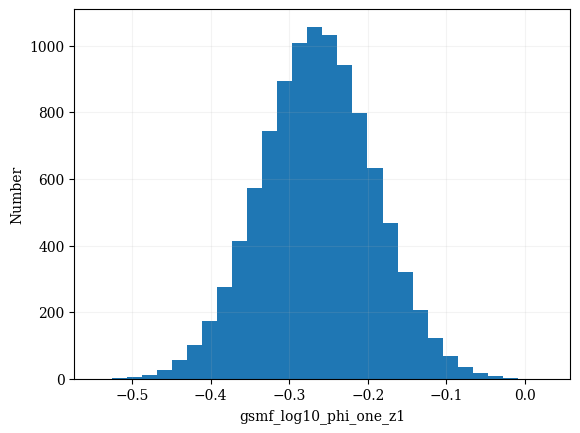

In [16]:
# A histogram of the random samples taken
i = 4 # Index of parameter to plot
plt.hist(space.param_samples.transpose()[i], bins=30)
plt.xlabel(space.param_names[i])
plt.ylabel('Number');

In [17]:
def bhmf(mass, dct, redz):
    try:
        # These are the parameters for the double GSMF, these are what holodeck uses in param_spaces.py
        log10_phi1 = [dct['gsmf_log10_phi_one_z0'], dct['gsmf_log10_phi_one_z1'], dct['gsmf_log10_phi_one_z2']]
        log10_phi2 = [dct['gsmf_log10_phi_two_z0'], dct['gsmf_log10_phi_two_z1'], dct['gsmf_log10_phi_two_z2']]
        log10_mstar = [dct['gsmf_log10_mstar_z0'], dct['gsmf_log10_mstar_z1'], dct['gsmf_log10_mstar_z2']]
        alpha1 = dct['gsmf_alpha_one']
        alpha2 = dct['gsmf_alpha_two']
        gsmf = sams.GSMF_Double_Schechter(log10_phi1, log10_phi2, log10_mstar, alpha1, alpha2) # Double Schechter GSMF from sams/components.py
    except:
        # These are the parameters for the single GSMF, these are what holodeck uses in param_spaces_classic.py
        log10_phi1 = dct['gsmf_phi0_log10']
        log10_mstar = dct['gsmf_mchar0_log10']
        gsmf = sams.GSMF_Schechter(phi0=log10_phi1, mchar0_log10=log10_mstar) # Single Schechter GSMF from sams/components.py

    mmb = holo.host_relations.MMBulge_KH2013(mamp_log10 = dct['mmb_mamp_log10'],
                                            mplaw = dct['mmb_plaw'],
                                            scatter_dex = dct['mmb_scatter_dex'])

    return gsmf.mbh_mass_func_conv(10**mass * MSOL, redz, mmbulge=mmb, scatter=True), None # Calculate BHMF from sams/components.py

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
/var/folders/7z/7081q7x964b7rf4h4sy5t4qw0000gs/T/ipykernel_94433/1227902890.py:11: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log (M_\mathrm{BH} / M_\odot)$', fontsize=25)
/var/folders/7z/7081q7x964b7rf4h4sy5t4qw0000gs/T/ipykernel_94433/1227902890.py:12: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log (\Phi / \mathrm{Mpc}^{-3} /\mathrm{dex})$', fontsize=25)


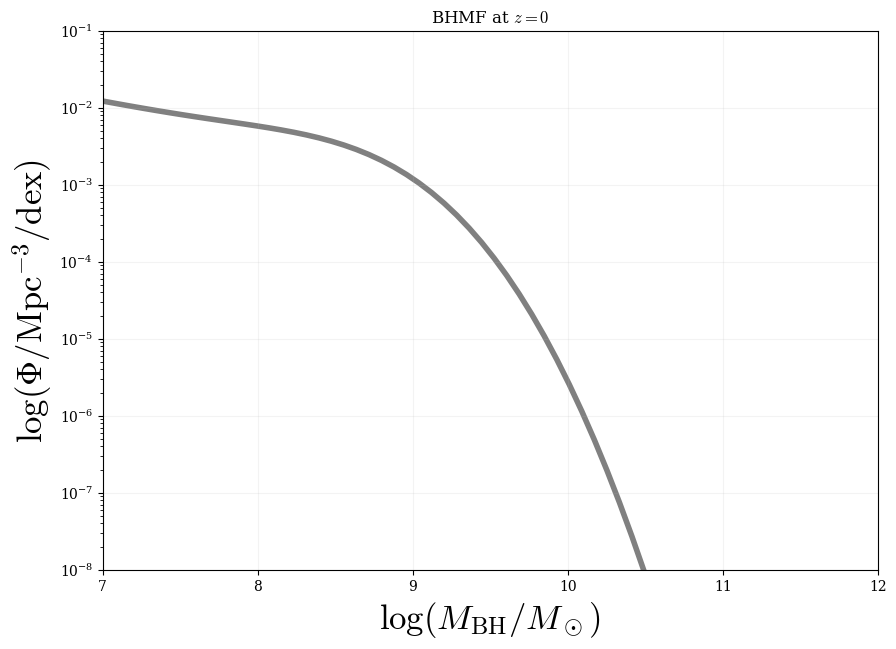

In [18]:
plt.figure(figsize=(10, 7))

masses = np.linspace(5, 13, 100)
z = 0 # Redshift to evaluate BHMF, see what happens when you change this to other values

dndm, error = bhmf(masses, fiducial_dct, redz=z) # Calculate BHMF
plt.plot(masses, dndm, c='grey', lw=4, zorder=0, label='$z = {}$'.format(z))

plt.yscale('log')

plt.xlabel('$\log (M_\mathrm{BH} / M_\odot)$', fontsize=25)
plt.ylabel('$\log (\Phi / \mathrm{Mpc}^{-3} /\mathrm{dex})$', fontsize=25)

plt.xlim(7, 12)
plt.ylim(1e-8, 10**-1);
plt.title('BHMF at $z = {}$'.format(z));

<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
/var/folders/7z/7081q7x964b7rf4h4sy5t4qw0000gs/T/ipykernel_94433/1257077668.py:15: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log (M_\mathrm{BH} / M_\odot)$', y=-0.1, fontsize=35)


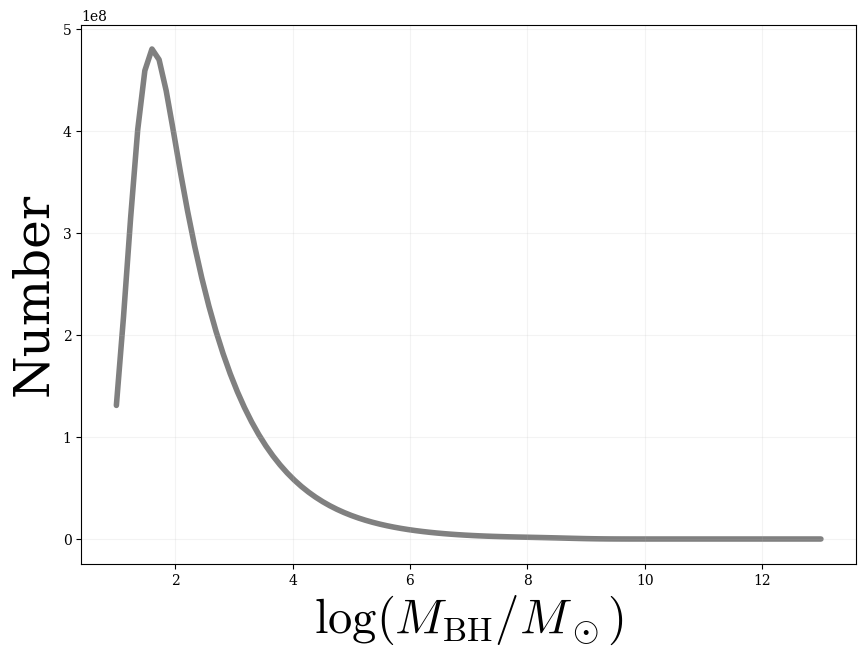

In [19]:
plt.figure(figsize=(10, 7))

masses = np.linspace(1, 13, 100)
z = 0.1
V = cosmo.comoving_volume(z).to('Mpc3').value # Comoving volume out to redshift z
dndm, error = bhmf(masses, fiducial_dct, redz=z)
# plt.plot(masses, dndm, c='grey', lw=4, zorder=0)

plt.plot(masses, dndm*V, c='grey', lw=4, zorder=0) # Multiply by volume to get number

qs = np.linspace(1e-3, 1, len(masses))

# plt.yscale('log')

plt.xlabel('$\log (M_\mathrm{BH} / M_\odot)$', y=-0.1, fontsize=35)
plt.ylabel('Number', x=0.08, fontsize=35);

# plt.xlim(9, 10.5);
# plt.ylim(0, 0.5*10**6);

Now you can test the impact of different parameters on the number density of black holes

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
/var/folders/7z/7081q7x964b7rf4h4sy5t4qw0000gs/T/ipykernel_94433/1802768764.py:21: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log (M_\mathrm{BH} / M_\odot)$', y=-0.1, fontsize=25)
/var/folders/7z/7081q7x964b7rf4h4sy5t4qw0000gs/T/ipykernel_94433/1802768764.py:22: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log (\Phi / \mathrm{Mpc}^{-3} /\mathrm{dex})$', x=0.08, fontsize=25)


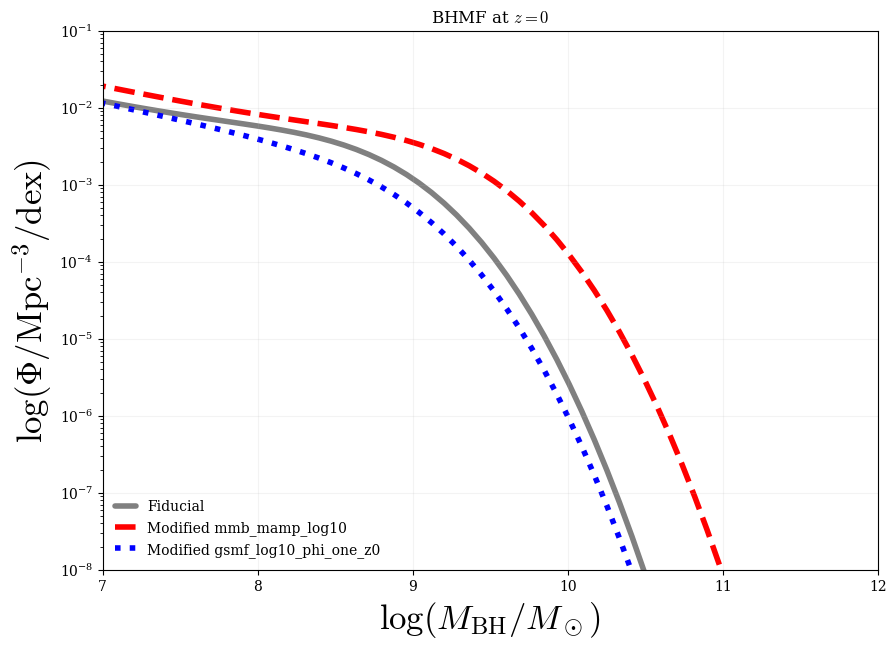

In [20]:
plt.figure(figsize=(10, 7))

masses = np.linspace(5, 13, 100)
z = 0 # Redshift to evaluate BHMF

dndm, error = bhmf(masses, fiducial_dct, redz=z) # Calculate fiducial BHMF
plt.plot(masses, dndm, c='grey', lw=4, zorder=0, label='Fiducial')

test_dct = fiducial_dct.copy()
test_dct['mmb_mamp_log10'] += 0.5 # Increase the normalization of the MMB relation
dndm, error = bhmf(masses, test_dct, redz=z) # Calculate BHMF with modified parameters
plt.plot(masses, dndm, c='r', lw=4, zorder=0, label='Modified mmb_mamp_log10', ls='--')

test1_dct = fiducial_dct.copy()
test1_dct['gsmf_log10_phi_one_z0'] -= 0.5 # Increase the normalization of the MMB relation
dndm, error = bhmf(masses, test1_dct, redz=z) # Calculate BHMF with modified parameters
plt.plot(masses, dndm, c='b', lw=4, zorder=0, label='Modified gsmf_log10_phi_one_z0', ls=':')

plt.yscale('log')

plt.xlabel('$\log (M_\mathrm{BH} / M_\odot)$', y=-0.1, fontsize=25)
plt.ylabel('$\log (\Phi / \mathrm{Mpc}^{-3} /\mathrm{dex})$', x=0.08, fontsize=25)

plt.xlim(7, 12)
plt.ylim(1e-8, 10**-1)
plt.legend(loc = 'lower left', frameon=False)
plt.title('BHMF at $z = {}$'.format(z));